### Imports

In [1]:
import warnings

import torch

from src.config import CONFIG
from src.run_train import train_and_benchmark
from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.types.model_type import ModelType
from src.utils.hyperparameter_sweep_utils import run_hyperparameter_sweep
from src.utils.plotting_utils import plot_training_history

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL = ModelType.CNN
DATASET = DatasetType.AUDIOMNIST
FILTERBANK = FilterbankType.MEL

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
if CONFIG.hyperparameter_tuning.should_run:
    run_hyperparameter_sweep(device, MODEL, DATASET, FILTERBANK)

### Training

Hyperparameters used: {'lr': 0.007039879588220245, 'model_init': {}}

Training CNN...
[Epoch 1/5]


Validating: 100%|██████████| 12/12 [00:09<00:00,  1.31batches/s]


Train Loss: 0.27 | Train Accuracy: 92.67% | Val Loss: 0.08 | Val Accuracy: 98.03%
Epoch Duration: 27s | Total Time Elapsed: 27s

[Epoch 2/5]


Validating: 100%|██████████| 12/12 [00:01<00:00,  6.20batches/s]


Train Loss: 0.03 | Train Accuracy: 99.29% | Val Loss: 0.04 | Val Accuracy: 98.90%
Epoch Duration: 13s | Total Time Elapsed: 40s

[Epoch 3/5]


...

Train Loss: 0.01 | Train Accuracy: 99.82% | Val Loss: 0.03 | Val Accuracy: 99.23%
Epoch Duration: 11s | Total Time Elapsed: 63s

[Epoch 5/5]


Validating: 100%|██████████| 12/12 [00:01<00:00,  6.76batches/s]

Train Loss: 0.01 | Train Accuracy: 99.84% | Val Loss: 0.02 | Val Accuracy: 99.37%
Epoch Duration: 12s | Total Time Elapsed: 75s

Training completed in 75s
Best model had an accuracy of 99.37%
Running benchmark on test set...



Testing: 100%|██████████| 12/12 [00:02<00:00,  5.06batches/s]


Test Accuracy: 99.60% | Total MACs: 694,778 | Total ACs: 0


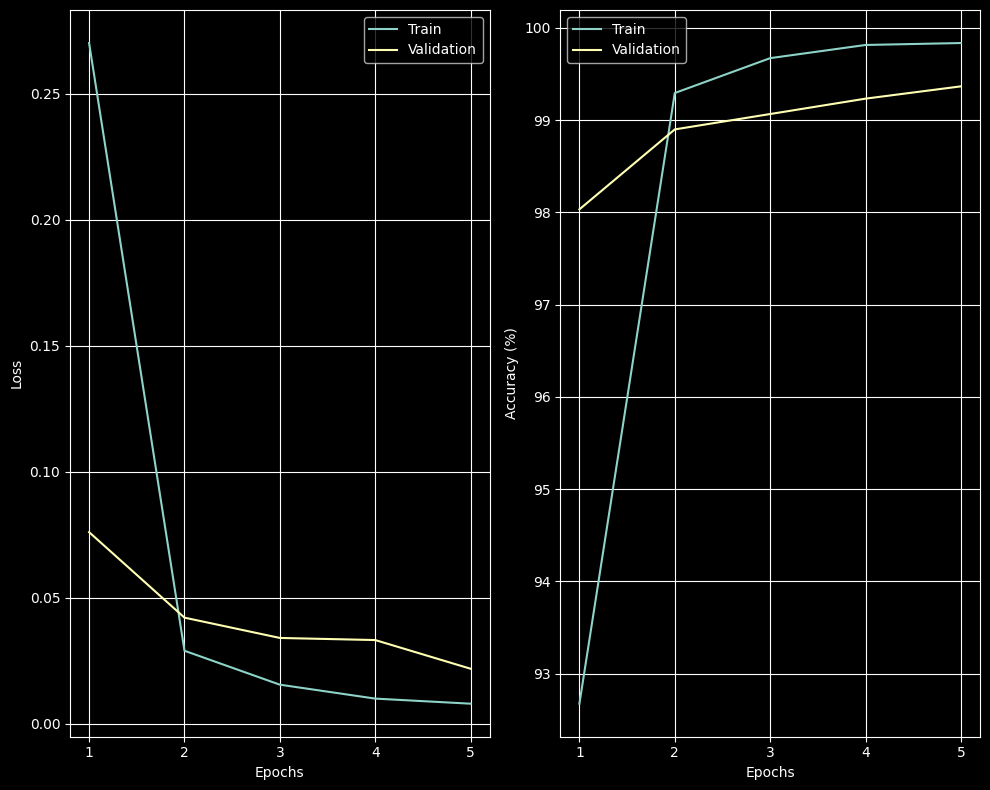

In [5]:
results = train_and_benchmark(device, MODEL, DATASET, FILTERBANK)
plot_training_history(**results['epoch_history'])